# Нейронные сети



In [15]:
from setup import *

Ноутбук основан на лекциях К. В. Воронцова и Р. Г. Нейчева

Мы уже изучили несколько основных алгоритмов классического ML, сейчас мы ныряем глубже в DL. Это отдельное пространство, отдельная история...



![alt](../data/1.png)

![alt](../data/11.png)

![alt](../data/13.webp)

![alt](../data/14.webp)

# Вспоминаем, а какую задачу мы вообще решаем?

Дано: выборка $X^l = (x_i, y_i)_{i=1}^{l}, x_i \in \mathbb{R}^n$


## Задача регрессии:

$$Q(w, X^l) = \sum_{i=1}^l L(a(x_i, w), y) \rightarrow \min_w$$

## Задача классификации (бинарной классификации):

$$ Q(w, X^l) =  \sum_{i=1}^l L(g(x_i, w)y_i) = \sum_{i=1}^l L(M_i(w)) \rightarrow \min_w$$

![alttext](../data/2.png)

## Линейная модель нейрона

$$a(x, w) = \sigma(\sum_{j=1}^n w_jf_j(x) - w_0)$$

* $f_j(x)$ - $j$-ый признак объекта $x$
* $w_j$ - $j$ - ый вес паризнака
* $w_0$ - порог активации
* $\sigma(z)$ - функция активации

![alt](../data/3.png)

**Источник**: К. В. Воронцов "[Глубокие нейронные сети](http://www.machinelearning.ru/wiki/images/7/71/Voron-ML-DeepLearning-slides.pdf)"

In [1]:
# Попробуем что-нибудь реализовать при помощи одного нейрона

import numpy as np

class Neuron:
    def __init__(self, input, w, w0) -> None:
        self.input: np.ndarray = np.array(input)
        self.w: np.ndarray = np.array(w)
        self.w0 = w0
        self.is_activated = False
        self.__value = 0.0

    @property
    def value(self):
        return self.__value

    def compile(self):
        self.__value = np.sum(self.input * self.w) - self.w0

    def activate(self, func: callable) -> None: # type: ignore
        self.__value = func(self.__value)
        self.is_activated = True

    def __repr__(self) -> str:
        return f"Neuron(value={self.__value}; activated={self.is_activated})"

    def __str__(self) -> str:
        return f"Neuron(value={self.__value}; activated={self.is_activated})"


In [2]:
# Act

# Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# The Heaviside step function
def heavised(x):     # [x >= 0]
    return np.heaviside(x, 0.5)

In [3]:
X = [1, 1]
n1 = Neuron(input=X, w=[1, 1], w0=1.5)  #  [1 * 1 + 1 * 1 - 1.5 >= 0] ->
n1.compile()
n1.activate(sigmoid)
n1.value

np.float64(0.6224593312018546)

In [4]:
X = [1, 0]
n2 = Neuron(input=X, w=[1, 1], w0=0.5) #  [1 * 1 + 0 * 1 - 0.5 >= 0] ->
n2.compile()
n2.activate(heavised)
n2.value

np.float64(1.0)

In [5]:
X = [0]
n3 = Neuron(input=X, w=[-1], w0=-0.5)  # [1 * (-1) + 0.5 >= 0]
n3.compile()
n3.activate(heavised)
n3.value

# w1 = 1 w2 = 1 w0 = 1.5
# x = [x1, x2]
# s = x1*w1 + x2*w2 -w0 = x1 + x2 - 1.5     ->  [x1 + x2 - 1.5 > 0]  = [1 + 1 - 1.5 > 0]

np.float64(1.0)

![alt](../data/4.png)

In [ ]:
X= [1, 0]

n1 = Neuron(input=X, w=[1, 1], w0=0.5)
n1.compile()
n1.activate(heavised)

n2 = Neuron(input=X, w=[1, 1], w0=1.5)
n2.compile()
n2.activate(heavised)

n3 = Neuron(input=[n1.value, n2.value], w=[1, -1], w0=0.5)
n3.compile()
print(n3)
n3.activate(heavised)
n3.value

# f1 = Xw1 + b1  -> g1(f1)
# f2 = Xw2 + b2 -> g2(f2)
# f3 = <g1g2>w3 + b3 -> g3(f3)
# g3(X, w1, w2, w3, b1, b2, b3, f3, f2, f1, g2, g1) =

Neuron(value=0.5; activated=False)


np.float64(1.0)

![alt](../data/5.png)

## Почему это вообще работает?



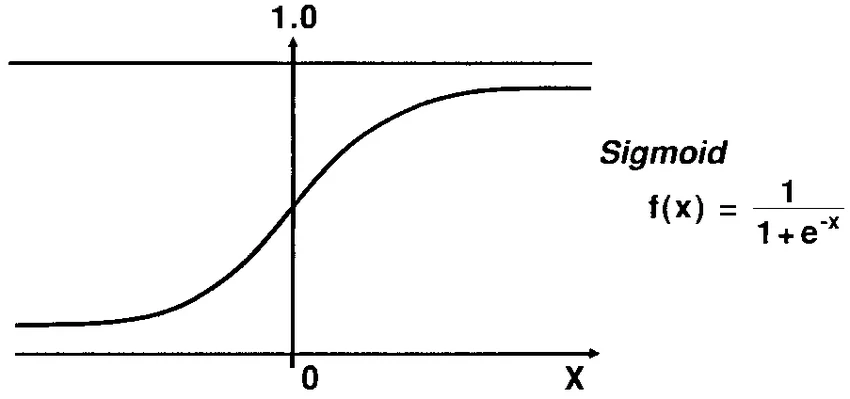

### Теорема Цыбенко об аппроксимации (Cybenko Universal Approximation Theorem)

#### Формулировка

Пусть $\sigma: \mathbb{R} \to \mathbb{R}$ — **сигмоидальная** (непрерывная и неубывающая) функция, такая что:

$$
\lim_{x \to +\infty} \sigma(x) = 1, \quad \lim_{x \to -\infty} \sigma(x) = 0
$$

(например, логистическая функция $\sigma(x) = \frac{1}{1+e^{-x}}$).
___

Если $\sigma(z)$ — непрерывная сигмоида, то для любой непрерывной на $[0,1]^n$ функции $f(x)$ существуют такие значения параметров $w_h \in \mathbb{R}^n$, $w_0 \in \mathbb{R}$, $\alpha_h \in \mathbb{R}$, что двухслойная сеть

$$
a(x) = \sum_{h=1}^H \alpha_h \sigma(\langle x, w_h \rangle + w_0)
$$

равномерно приближает $f(x)$ с любой точностью $\varepsilon$:

$$
|a(x) - f(x)| < \varepsilon,
$$

для всех $x \in [0,1]^n$.
___

#### Комментарии

- Теорема верна для любой ограниченной, немонотонно убывающей и **не полиномиальной** сигмоидальной активации.
- Размер скрытого слоя $N$ не фиксирован и зависит от $\varepsilon$ и $f$.

#### Следствие для нейронных сетей

Однослойная (или же двухслойная вход и выход [Зависит от интерпретации]) нейронная сеть с сигмоидальной активацией способна аппроксимировать **любую** непрерывную функцию на компакте с произвольной точностью.

[Интерактивный пример](https://playground.tensorflow.org)

Давайте наконец формально определим, что такое нейронная сеть

**Нейронная сеть (neural network; nn)** - композиция линейных и нелинейных преобразований. В целом, нейронная сеть представляет собой сложную (параметрическую) функцию $f$, задающую отображение из исходного признакового пространства $\mathbb{X}$ в целевое пространство (target) $\mathbb{Y}$

$$f: \mathbb{X} \rightarrow \mathbb{Y}$$

Нейронные сети можно представлять себе, как конструктор LEGO: они представляют из себя последовательные преобразования (слои и функции активаации)

**Слой (layer)** - некоторая функция\преобразование над исходными данными. Простейший пример: линейный слой, являющийся линейный преобразование над входящими данными (т.е. просто афинное преобразование $WX + b$, как в линейной регрессии)

**Функция активации (activation function)** - нелинейное преобразование, примеяющееся ко всем данным, пришедшим на вход поэлементно. Благодаря функциям активации нейронные сети способны преобразовывать данные **нелинейным** образом, что позволяет порождать более информативные признаковые описания.

**Функция потерь (loss function; loss)** - функция потерь, оценивающая качество полученного предсказания. Как правило, такие функции должны быть **гладкими**.

**Источник**: Р. Г. Нейчев

Даже самые сложные нейронные сети обычно собираются из относительно простых блоков, подобных этим. Таким образом, их можно представить в виде вычислительного графа (computational graph), где промежуточным вершинам соответствуют преобразования. На иллюстрации ниже приведён вычислительный граф для логистической регрессии.

![alt](../data/6.webp)

Графы могут быть и более сложными, в том числе нелинейными:

![alt](../data/7.webp)

Нейросеть, в которой есть только линейные слои и различные функции активации, называют полносвязной (fully connected) нейронной сетью или многослойным перцептроном (multilayer perceptron, MLP).

`Примечание`:
В литературе, увы, нет единства терминологии.

Так, например, никто не мешает нам объявить «единым и неделимым слоем» композицию линейного слоя и активации (в ознаменование того, что мы почти никогда не используем просто линейный слой без нелинейности). Например, в фреймворке keras активацию можно указать в линейном слое в качестве параметра.

Также в ряде источников слоями называется то, что мы называем промежуточными представлениями. Нам, впрочем, кажется, что промежуточные результаты $X^i$ правильнее называть именно `представлениями`: ведь это новые признаковые описания, представляющие исходные объекты. Кроме того, во всех нейросетевых фреймворках слои — это именно преобразования, поэтому и нам кажется правильным объявлять слоями именно преобразования, связывающие промежуточные представления.

А вот и настоящий пример из реальной жизни. GoogLeNet (она же Inception-v1), показавшая SotA-результат на ILSVRC 2014 (ImageNet challenge), выглядит так:

![alt](../data/8.webp)

Здесь каждый кирпичик — это некоторое относительно простое преобразование, а белым помечены входы и выходы вычислительного графа.

Современные же сети часто выглядят и ещё сложней, но всё равно они собираются из достаточно простых кирпичиков-слоёв.

Иногда нейронные сети ещё изображают так:

![alt](../data/10.png)

## Архитектуры для простейших задач

Как мы уже упоминали выше, нейросети — это универсальный конструктор, который из простых блоков позволяет собрать орудия для решения самых разных задач. Давайте посмотрим на конкретные примеры. Безусловно, мир намного разнообразнее того, что мы покажем вам в этом параграфе, но с чего-то ведь надо начинать, не так ли?

В тех несложных ситуациях, которые мы сейчас рассмотрим, архитектура будет отличаться лишь самыми последними этапами вычисления (у сетей будут разные «головы»). Для иллюстрации приведём примеры нескольких игрушечных архитектур для решения игрушечных задач классификации и регрессии на двумерных данных:

![alt](../data/9.webp)

In [6]:
# Модуль torch - основа-основ современной инженерии ИИ
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
# Подготовка данных
iris = load_iris()
X, y = iris.data, iris.target

In [8]:
# Масштабируем признаки (для нейросетей это важно. Подумайте почему..)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Переводим в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [10]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 10)  # Вход: 4 признака, скрытый слой: 10 нейронов
        self.output = nn.Linear(10, 3)  # Выход: 3 класса (вида ирисов)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [11]:
model = SimpleNet()
print(model.parameters())
criterion = nn.CrossEntropyLoss()  # loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

<generator object Module.parameters at 0x000001DE97039E00>


In [12]:
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

In [13]:
with torch.no_grad():
    predicts = model(X_test)
    accuracy = (predicts.argmax(1) == y_test).float().mean()
    print(f"Accuracy на тестовой выборке: {accuracy:.2f}")

Accuracy на тестовой выборке: 1.00


In [17]:
# ReLU, Tanh, Softmax
run_animate(nn.ReLU)

Чтобы торч делал обучение и работу с градиентами за нас, нужно рассказать ему, как именно обновлять веса, зная градиенты. Есть более хитрые способы оптимизации нейронных сетей, чем градиентый спуск, который мы написали выше. Градиентный спуск или его стохастическая вариация (SGD) не всегда быстро находит минимум на поверхности функции потерь (если вообще находит).

Вот есть гифка, где разные алгоритмы оптимизации (оптимайзеры) ищут минимум. Нашли SGD на этой картинке? Он застрял посередине седла

![title](https://cs231n.github.io/assets/nn3/opt1.gif)

## Функции активации

Их достаточно [много](https://en.wikipedia.org/wiki/Activation_function#Folding_activation_functions)

С ними можно экспериментировать.  
Но в среднем можно ставить `nn.ReLU` и норм.  


## Для нейронок же нужны GPU?

Да, если у вас есть видюха nvidia*, можно обучать и запускать нейронки.  
Так будет на несколько порядков бысрее чем на процессоре. 

\* на AMD тоже можно, но количество испытанной БОЛИ будет гораздо больше

Проверим, есть ли у нас GPU:



In [30]:
# если false, то торч не видит видеокарту
torch.cuda.is_available()

True

Отличие в обучении будет только в том, что надо попросит торч перенести модель и данные на гпу

```python
def train(model, loss, optimizer, epoches):
    # переместим все "числа" на видюху, если она есть
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    y = ys.to(device)
    x = xs.to(device)
```

И напоследок ещё одна [песочница](https://mlu-explain.github.io/neural-networks/)

## Итог

![alt](../data/12.jpg)


**Фундаментальные концепции**
1. Сети учатся на данных $(x_i, y_i)$, минимизируя функцию потерь (например, для регрессии или классификации).

2. Нейронная сеть - это линейная модель НА СТЕРОИДАХ!!

3. Ключевая теорема: Теорема Цыбенко (Universal Approximation Theorem) — однослойная сеть с сигмоидальной активацией может аппроксимировать любую непрерывную функцию с любой точностью. Это теоретическая основа "всемогущества" нейросетей.

4. Формальное определение: Нейросеть — это сложная параметрическая функция $f: \mathbb{X} \rightarrow \mathbb{Y}$, состоящая из последовательных слоев (линейных преобразований) и функций активации (нелинейностей, например, ReLU).